# Customer & Campaign Intelligence — Data Audit

**Proyecto:** Segmentación de clientes y análisis de respuesta a campañas de marketing.

**Objetivo de este notebook:** realizar una auditoría de calidad de datos sobre el 
dataset `marketing_campaign.csv`, antes de cualquier limpieza o transformación, 
identificando nulos, duplicados, valores atípicos y tipos de dato incorrectos.

**Fuente de datos:** [Kaggle — "Marketing Campaign" dataset](https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign)
(basado en Parr-Rud, O. *Business Analytics Using SAS Enterprise Guide and 
SAS Enterprise Miner*, SAS Institute, 2014). Los datos se utilizan como base para desarrollar el análisis y demostrar un flujo de trabajo completo de Data Analytics orientado a negocio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/raw/marketing_campaign.csv', sep=';')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
df.duplicated().sum()
df["ID"].duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df[df["Income"].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


<Axes: ylabel='Year_Birth'>

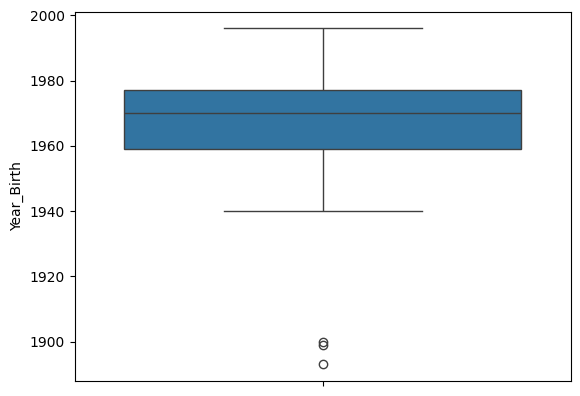

In [10]:
#outlier
df["Year_Birth"].sort_values().head(10)


sns.boxplot(data=df["Year_Birth"])

In [11]:
df["Year_Birth"].sort_values(ascending=False).head(10)

1170    1996
46      1996
747     1995
1850    1995
696     1995
995     1995
2213    1995
417     1994
1163    1994
914     1994
Name: Year_Birth, dtype: int64

In [12]:
df["Marital_Status"].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [13]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

<Axes: ylabel='Income'>

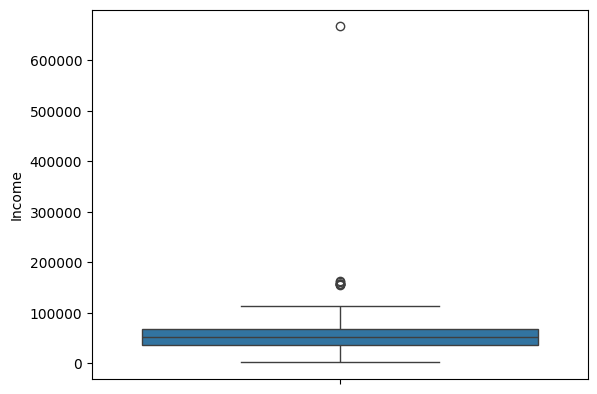

In [14]:
df["Income"].sort_values(ascending=False).head(10)

sns.boxplot(df["Income"])

In [15]:
df["Z_CostContact"].unique()

array([3])

In [16]:
df["Z_Revenue"].unique()

array([11])

In [17]:
df["Dt_Customer"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype 
--------------  ----- 
2240 non-null   object
dtypes: object(1)
memory usage: 17.6+ KB


In [18]:
df["MntWines"].sort_values().head(10)    

444     0
445     0
862     0
1170    0
1171    0
2091    0
136     0
1780    0
738     0
893     0
Name: MntWines, dtype: int64

In [19]:
df["MntWines"].value_counts()

MntWines
2       42
5       40
1       37
6       37
4       33
        ..
934      1
1115     1
1486     1
835      1
1245     1
Name: count, Length: 776, dtype: int64

In [20]:
df["MntMeatProducts"].sort_values(ascending=False).head(10)    

1653    1725
21      1725
687     1622
2228    1607
164     1582
1358     984
1808     981
456      974
2109     968
1031     961
Name: MntMeatProducts, dtype: int64

In [21]:
df["MntMeatProducts"].value_counts()

MntMeatProducts
7      53
5      50
11     49
8      46
6      43
       ..
883     1
450     1
498     1
164     1
182     1
Name: count, Length: 558, dtype: int64

In [22]:
df.select_dtypes(include="object").columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

In [23]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].value_counts())
    print("--------------------------------")
    

Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
--------------------------------
Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
--------------------------------
Dt_Customer
Dt_Customer
2012-08-31    12
2014-05-12    11
2013-02-14    11
2012-09-12    11
2014-05-22    10
              ..
2013-11-01     1
2013-08-10     1
2012-10-11     1
2012-12-20     1
2014-01-09     1
Name: count, Length: 663, dtype: int64
--------------------------------


In [24]:
df.select_dtypes(include="object")

,Education,Marital_Status,Dt_Customer
0,Graduation,Single,2012-09-04
1,Graduation,Single,2014-03-08
2,Graduation,Together,2013-08-21
3,Graduation,Together,2014-02-10
4,PhD,Married,2014-01-19
...,...,...,...
2235,Graduation,Married,2013-06-13
2236,PhD,Together,2014-06-10
2237,Graduation,Divorced,2014-01-25
2238,Master,Together,2014-01-24


## Auditoría de Datos — Hallazgos

**Duplicados:** ninguno (ni filas completas ni IDs repetidos).

**Nulos:** `Income` tiene 24 valores nulos (~1%), sin patrón claro por educación 
ni estado civil → candidato a imputar con la mediana.

**Outliers:**
- `Year_Birth`: 3 valores imposibles (1893, 1899, 1900) → candidatos a eliminar.
- `Income`: 1 valor extremo aislado (666,666) → candidato a eliminar o tratar como outlier.

**Categorías inválidas:**
- `Marital_Status`: 7 registros con categorías basura (`Alone`, `Absurd`, `YOLO`) 
  de 2,240 → candidatas a fusionar o eliminar.

**Columnas sin valor analítico:**
- `Z_CostContact` y `Z_Revenue`: valor constante en todo el dataset (3 y 11) 
  → candidatas a eliminar.

**Tipos de dato incorrectos:**
- `Dt_Customer`: almacenada como texto (`str`), no como fecha 
  → requiere conversión con `pd.to_datetime()` antes de usarla en cálculos.